In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import joblib
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold,
    cross_val_score, LeaveOneOut)
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve)
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# ── PATHS ──────────────────────────────────────────────────
TRAIN_PATH = '../data/kaggle_spiral/spiral/training'
TEST_PATH  = '../data/kaggle_spiral/spiral/testing'
IMG_SIZE   = 128

# ── LOAD FUNCTION ──────────────────────────────────────────
def load_images(base_path, img_size=128):
    images  = []
    labels  = []
    names   = []
    
    for label, class_name in enumerate(
            ['healthy', 'parkinson']):
        folder = os.path.join(base_path, class_name)
        
        if not os.path.exists(folder):
            print(f"Not found: {folder}")
            continue
        
        files = sorted([
            f for f in os.listdir(folder)
            if f.lower().endswith(
                ('.png','.jpg','.jpeg'))
        ])
        
        print(f"  {class_name}: {len(files)} images")
        
        for filename in files:
            path = os.path.join(folder, filename)
            img = cv2.imread(path,
                             cv2.IMREAD_GRAYSCALE)
            
            if img is None:
                print(f"  Cannot read: {filename}")
                continue
            
            img = cv2.resize(img, (img_size, img_size))
            img = img / 255.0
            
            images.append(img)
            labels.append(label)
            names.append(filename)
    
    return (np.array(images),
            np.array(labels),
            names)

print("Loading training images...")
X_train_img, y_train, train_names = load_images(
    TRAIN_PATH, IMG_SIZE)

print("\nLoading testing images...")
X_test_img, y_test, test_names = load_images(
    TEST_PATH, IMG_SIZE)

print(f"\nTraining: {X_train_img.shape}")
print(f"Testing:  {X_test_img.shape}")
print(f"\nTraining labels: "
      f"{np.unique(y_train, return_counts=True)}")
print(f"Testing labels:  "
      f"{np.unique(y_test, return_counts=True)}")

Loading training images...
  healthy: 36 images
  parkinson: 36 images

Loading testing images...
  healthy: 15 images
  parkinson: 15 images

Training: (72, 128, 128)
Testing:  (30, 128, 128)

Training labels: (array([0, 1]), array([36, 36]))
Testing labels:  (array([0, 1]), array([15, 15]))


In [9]:
def extract_spiral_features(image):
    """
    Extract clinically meaningful features
    from one spiral drawing image.
    
    image: numpy array, shape (128,128), values 0-1
    """
    # Convert back to uint8 for OpenCV operations
    img_uint8 = (image * 255).astype(np.uint8)
    
    # ── BINARIZE IMAGE ─────────────────────────────────────
    # Convert to black and white
    _, binary = cv2.threshold(
        img_uint8, 127, 255, cv2.THRESH_BINARY_INV)
    
    # ── EDGE DETECTION ─────────────────────────────────────
    # Find edges — the spiral line
    edges = cv2.Canny(img_uint8, 50, 150)
    
    # ── FIND CONTOURS ──────────────────────────────────────
    # Contours = the drawn spiral lines
    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
    
    # ── BASIC IMAGE STATISTICS ─────────────────────────────
    # Standard deviation of pixel intensities
    # High std = more irregular = more tremor
    pixel_std  = np.std(image)
    pixel_mean = np.mean(image)
    pixel_max  = np.max(image)
    
    # ── GRADIENT FEATURES ─────────────────────────────────
    # Sobel gradients measure edge sharpness
    # Shaky lines have irregular gradients
    sobelx = cv2.Sobel(img_uint8, cv2.CV_64F, 1, 0,
                        ksize=3)
    sobely = cv2.Sobel(img_uint8, cv2.CV_64F, 0, 1,
                        ksize=3)
    
    gradient_magnitude = np.sqrt(
        sobelx**2 + sobely**2)
    
    grad_mean = np.mean(gradient_magnitude)
    grad_std  = np.std(gradient_magnitude)
    grad_max  = np.max(gradient_magnitude)
    
    # ── LAPLACIAN (blur measure) ───────────────────────────
    # Tremor causes blurry, thick lines
    laplacian = cv2.Laplacian(img_uint8, cv2.CV_64F)
    laplacian_var = np.var(laplacian)
    laplacian_mean = np.mean(np.abs(laplacian))
    
    # ── CONTOUR FEATURES ──────────────────────────────────
    if len(contours) > 0:
        # Largest contour = main spiral line
        largest = max(contours, key=cv2.contourArea)
        
        contour_area      = cv2.contourArea(largest)
        contour_perimeter = cv2.arcLength(
            largest, True)
        
        # Circularity
        # Perfect circle = 1.0
        # Irregular shape = lower value
        if contour_perimeter > 0:
            circularity = (4 * np.pi * contour_area /
                          (contour_perimeter ** 2))
        else:
            circularity = 0
        
        # Convex hull — measures how convex the shape is
        hull = cv2.convexHull(largest)
        hull_area = cv2.contourArea(hull)
        
        # Solidity — area/hull area
        # Lower solidity = more irregular = tremor
        solidity = (contour_area / hull_area
                    if hull_area > 0 else 0)
        
        # Bounding rectangle aspect ratio
        x, y, w, h = cv2.boundingRect(largest)
        aspect_ratio = w / (h + 1e-10)
        
        # Extent — contour area / bounding rect area
        extent = (contour_area / (w * h)
                  if w * h > 0 else 0)
        
        num_contours = len(contours)
        
    else:
        contour_area      = 0
        contour_perimeter = 0
        circularity       = 0
        solidity          = 0
        aspect_ratio      = 0
        extent            = 0
        num_contours      = 0
    
    # ── TEXTURE FEATURES ──────────────────────────────────
    # Local Binary Pattern approximation
    # Measures texture regularity
    
    # Horizontal and vertical difference images
    diff_h = np.abs(np.diff(image, axis=1))
    diff_v = np.abs(np.diff(image, axis=0))
    
    texture_h_mean = np.mean(diff_h)
    texture_h_std  = np.std(diff_h)
    texture_v_mean = np.mean(diff_v)
    texture_v_std  = np.std(diff_v)
    
    # ── FREQUENCY FEATURES ────────────────────────────────
    # FFT of image rows — tremor creates
    # high frequency components
    fft_rows = np.fft.fft2(image)
    fft_mag  = np.abs(np.fft.fftshift(fft_rows))
    
    # High frequency energy ratio
    center = IMG_SIZE // 2
    radius = IMG_SIZE // 4
    
    # Create circular mask for high freq region
    y_grid, x_grid = np.ogrid[
        -center:IMG_SIZE-center,
        -center:IMG_SIZE-center
    ]
    mask = x_grid**2 + y_grid**2 > radius**2
    
    high_freq_energy = np.sum(fft_mag[mask])
    total_energy     = np.sum(fft_mag) + 1e-10
    high_freq_ratio  = high_freq_energy / total_energy
    
    # ── EDGE DENSITY ──────────────────────────────────────
    edge_density = np.sum(edges > 0) / edges.size
    
    # ── HOG-LIKE FEATURES ─────────────────────────────────
    # Histogram of gradient orientations
    # Captures the direction of spiral lines
    angle = np.arctan2(sobely, sobelx + 1e-10)
    
    # Bin angles into 8 directions
    hist, _ = np.histogram(
        angle.flatten(),
        bins=8,
        range=(-np.pi, np.pi),
        weights=gradient_magnitude.flatten()
    )
    hist = hist / (hist.sum() + 1e-10)
    
    # ── COMBINE ALL FEATURES ──────────────────────────────
    features = [
        # Basic statistics
        pixel_std,
        pixel_mean,
        pixel_max,
        
        # Gradient features
        grad_mean,
        grad_std,
        grad_max,
        
        # Laplacian
        laplacian_var,
        laplacian_mean,
        
        # Contour features
        contour_area,
        contour_perimeter,
        circularity,
        solidity,
        aspect_ratio,
        extent,
        num_contours,
        
        # Texture
        texture_h_mean,
        texture_h_std,
        texture_v_mean,
        texture_v_std,
        
        # Frequency
        high_freq_ratio,
        
        # Edge density
        edge_density,
    ]
    
    # Add HOG-like histogram (8 values)
    features.extend(hist.tolist())
    
    # Total: 29 features
    return np.array(features)

# ── EXTRACT FEATURES FROM ALL IMAGES ──────────────────────
print("Extracting features from training images...")
X_train_features = []
for i, img in enumerate(X_train_img):
    feat = extract_spiral_features(img)
    X_train_features.append(feat)
    if (i+1) % 20 == 0:
        print(f"  Processed {i+1}/{len(X_train_img)}")

X_train_features = np.array(X_train_features)

print("\nExtracting features from testing images...")
X_test_features = []
for img in X_test_img:
    feat = extract_spiral_features(img)
    X_test_features.append(feat)

X_test_features = np.array(X_test_features)

print(f"\nTraining feature matrix: {X_train_features.shape}")
print(f"Testing feature matrix:  {X_test_features.shape}")
print(f"Features per image: {X_train_features.shape[1]}")

Extracting features from training images...
  Processed 20/72
  Processed 40/72
  Processed 60/72

Extracting features from testing images...

Training feature matrix: (72, 29)
Testing feature matrix:  (30, 29)
Features per image: 29


C:\Users\nihal\AppData\Local\Temp\ipykernel_16568\1640446811.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\nihal\AppData\Local\Temp\ipykernel_16568\1640446811.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\nihal\AppData\Local\Temp\ipykernel_16568\1640446811.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\nihal\AppData\Local\Temp\ipykernel_16568\1640446811.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxpl

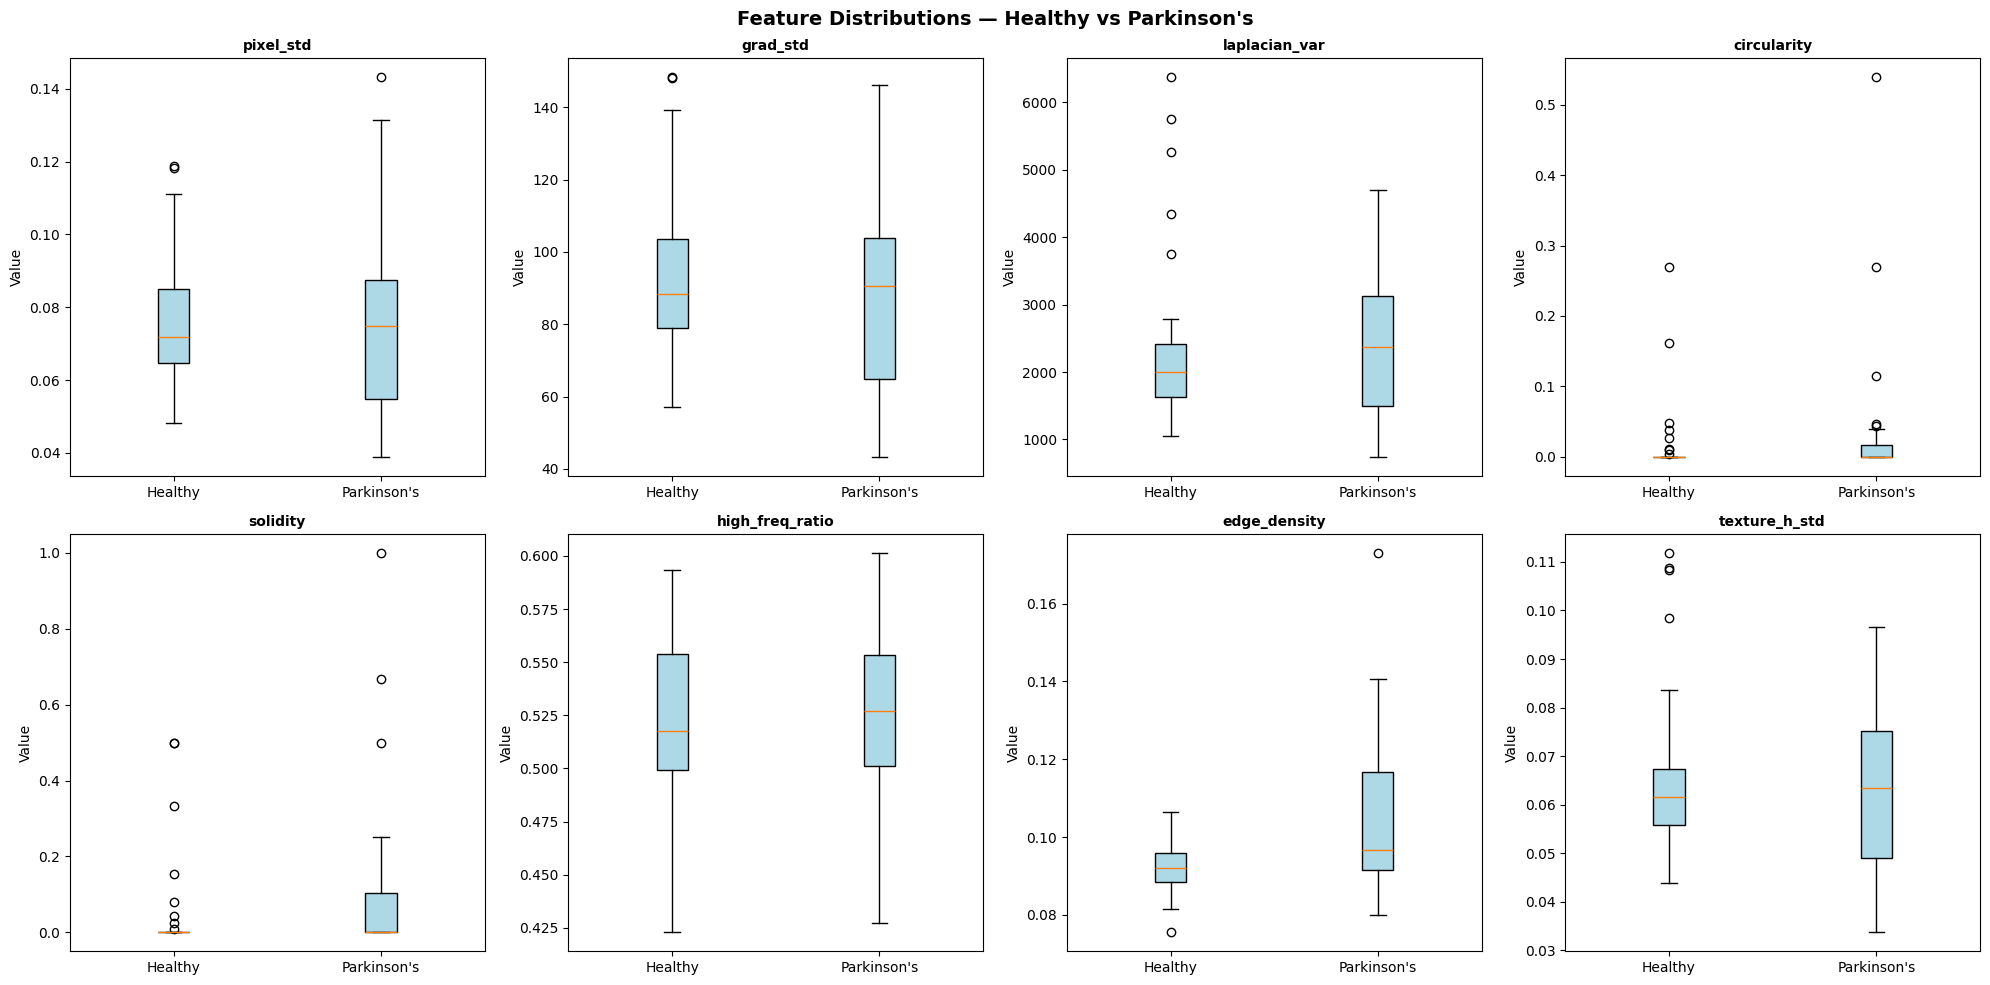


Feature                   Healthy    Parkinson
----------------------------------------------
pixel_std                  0.0759       0.0752
grad_std                  92.0946      87.0800
laplacian_var           2368.8230    2367.9997
circularity                0.0158       0.0323
solidity                   0.0456       0.0948
high_freq_ratio            0.5208       0.5268
edge_density               0.0918       0.1045
texture_h_std              0.0652       0.0625


In [10]:
# ── FEATURE NAMES ──────────────────────────────────────────
feature_names = [
    'pixel_std', 'pixel_mean', 'pixel_max',
    'grad_mean', 'grad_std', 'grad_max',
    'laplacian_var', 'laplacian_mean',
    'contour_area', 'contour_perimeter',
    'circularity', 'solidity',
    'aspect_ratio', 'extent', 'num_contours',
    'texture_h_mean', 'texture_h_std',
    'texture_v_mean', 'texture_v_std',
    'high_freq_ratio', 'edge_density',
    'hog_0', 'hog_1', 'hog_2', 'hog_3',
    'hog_4', 'hog_5', 'hog_6', 'hog_7'
]

# ── CREATE DATAFRAME ───────────────────────────────────────
df_train = pd.DataFrame(
    X_train_features,
    columns=feature_names
)
df_train['label'] = y_train

# ── PLOT KEY FEATURES ──────────────────────────────────────
key_features = [
    'pixel_std', 'grad_std',
    'laplacian_var', 'circularity',
    'solidity', 'high_freq_ratio',
    'edge_density', 'texture_h_std'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for ax, feat in zip(axes.flat, key_features):
    healthy    = df_train[df_train['label']==0][feat]
    parkinsons = df_train[df_train['label']==1][feat]
    
    ax.boxplot(
        [healthy.values, parkinsons.values],
        labels=['Healthy', "Parkinson's"],
        patch_artist=True,
        boxprops=dict(facecolor='lightblue'),
    )
    ax.set_title(feat, fontsize=10,
                  fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle(
    'Feature Distributions — Healthy vs Parkinson\'s',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../models/spiral_feature_boxplots.png',
            dpi=150)
plt.show()

# ── PRINT MEAN COMPARISON ──────────────────────────────────
print(f"\n{'Feature':<20} {'Healthy':>12} {'Parkinson':>12}")
print("-" * 46)
for feat in key_features:
    h = df_train[df_train['label']==0][feat].mean()
    p = df_train[df_train['label']==1][feat].mean()
    print(f"{feat:<20} {h:>12.4f} {p:>12.4f}")

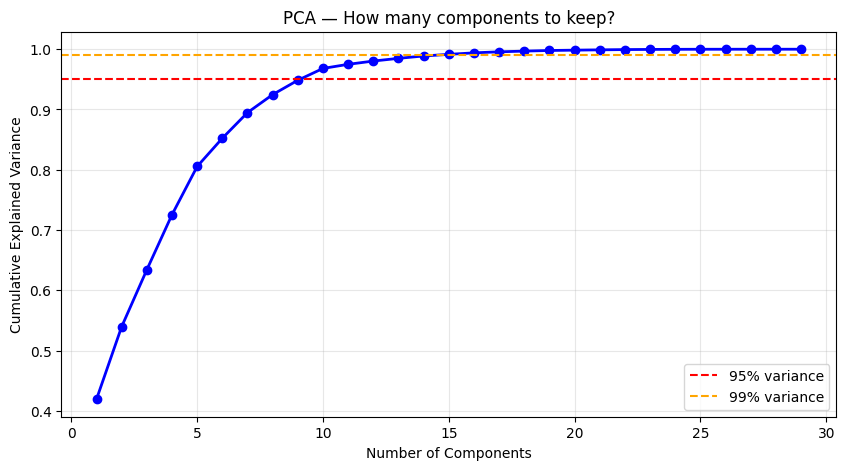

Components for 95% variance: 10
Components for 99% variance: 15

After PCA:
Training: (72, 10)
Testing:  (30, 10)


In [11]:
# ── PCA DIMENSIONALITY REDUCTION ──────────────────────────
# With 72 training samples and 29 features
# PCA reduces overfitting risk
# Keep enough components to explain 95% of variance

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# First scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled  = scaler.transform(X_test_features)

# Find optimal PCA components
pca_test = PCA()
pca_test.fit(X_train_scaled)

# Cumulative explained variance
cumvar = np.cumsum(pca_test.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar)+1), cumvar,
         'bo-', lw=2)
plt.axhline(y=0.95, color='red', linestyle='--',
            label='95% variance')
plt.axhline(y=0.99, color='orange', linestyle='--',
            label='99% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — How many components to keep?')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../models/spiral_pca_variance.png',
            dpi=150)
plt.show()

# Find components for 95% variance
n_components_95 = np.argmax(cumvar >= 0.95) + 1
n_components_99 = np.argmax(cumvar >= 0.99) + 1
print(f"Components for 95% variance: {n_components_95}")
print(f"Components for 99% variance: {n_components_99}")

# Apply PCA
pca = PCA(n_components=n_components_95,
          random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"\nAfter PCA:")
print(f"Training: {X_train_pca.shape}")
print(f"Testing:  {X_test_pca.shape}")

In [12]:
# ── TRAIN SVM ──────────────────────────────────────────────
print("Training SVM with Grid Search...")
print("Testing multiple parameter combinations...")
print()

# Use Leave One Out CV for small dataset
# LOO uses every sample as test once
# Much better than regular CV for small data
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()

# Grid search parameters
param_grid = {
    'C':      [0.01, 0.1, 1, 10, 100],
    'gamma':  ['scale', 'auto',
               0.001, 0.01, 0.1, 1.0],
    'kernel': ['rbf', 'linear', 'poly']
}

# Try all combinations
best_score = 0
best_params = {}
results = []

svm_base = SVC(probability=True, random_state=42)

for kernel in ['rbf', 'linear', 'poly']:
    for C in [0.01, 0.1, 1, 10, 100]:
        for gamma in ['scale', 'auto',
                      0.001, 0.01, 0.1]:
            
            svm = SVC(
                kernel=kernel,
                C=C,
                gamma=gamma,
                probability=True,
                random_state=42
            )
            
            # Cross validation score
            cv_scores = cross_val_score(
                svm,
                X_train_pca,
                y_train,
                cv=5,
                scoring='roc_auc'
            )
            
            mean_score = cv_scores.mean()
            
            results.append({
                'kernel': kernel,
                'C': C,
                'gamma': gamma,
                'mean_auc': mean_score,
                'std_auc': cv_scores.std()
            })
            
            if mean_score > best_score:
                best_score = mean_score
                best_params = {
                    'kernel': kernel,
                    'C': C,
                    'gamma': gamma
                }

results_df = pd.DataFrame(results).sort_values(
    'mean_auc', ascending=False)

print("Top 10 parameter combinations:")
print(results_df.head(10).to_string(index=False))
print(f"\nBest parameters: {best_params}")
print(f"Best CV AUC: {best_score:.4f}")

Training SVM with Grid Search...
Testing multiple parameter combinations...

Top 10 parameter combinations:
kernel     C gamma  mean_auc  std_auc
   rbf  1.00  auto  0.820408 0.155638
   rbf  1.00   0.1  0.820408 0.155638
   rbf  0.01  auto  0.815306 0.189818
   rbf  0.10   0.1  0.815306 0.189818
   rbf  0.01   0.1  0.815306 0.189818
   rbf  0.10  auto  0.815306 0.189818
   rbf  1.00 scale  0.798980 0.196375
   rbf  0.10 scale  0.785204 0.221692
   rbf  0.01 scale  0.785204 0.221692
   rbf 10.00   0.1  0.778571 0.129700

Best parameters: {'kernel': 'rbf', 'C': 1, 'gamma': 'auto'}
Best CV AUC: 0.8204


In [13]:
# ── TRAIN FINAL MODEL ──────────────────────────────────────
final_svm = SVC(
    kernel=best_params['kernel'],
    C=best_params['C'],
    gamma=best_params['gamma'],
    probability=True,
    random_state=42,
    class_weight='balanced'
)

final_svm.fit(X_train_pca, y_train)

# ── EVALUATE ───────────────────────────────────────────────
y_pred = final_svm.predict(X_test_pca)
y_prob = final_svm.predict_proba(X_test_pca)[:, 1]

print("── Spiral SVM Model Results ──\n")
print(classification_report(
    y_test, y_pred,
    target_names=['Healthy', "Parkinson's"]
))

auc = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc:.4f} ({auc*100:.2f}%)")

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\nDetailed breakdown:")
print(f"  Healthy correctly identified:    {tn}")
print(f"  Healthy wrongly flagged:         {fp}")
print(f"  Parkinson's missed:              {fn}")
print(f"  Parkinson's correctly detected:  {tp}")
print(f"\nSensitivity: {tp/(tp+fn)*100:.2f}%")
print(f"Specificity: {tn/(tn+fp)*100:.2f}%")

── Spiral SVM Model Results ──

              precision    recall  f1-score   support

     Healthy       0.73      0.53      0.62        15
 Parkinson's       0.63      0.80      0.71        15

    accuracy                           0.67        30
   macro avg       0.68      0.67      0.66        30
weighted avg       0.68      0.67      0.66        30

AUC Score: 0.6844 (68.44%)

Detailed breakdown:
  Healthy correctly identified:    8
  Healthy wrongly flagged:         7
  Parkinson's missed:              3
  Parkinson's correctly detected:  12

Sensitivity: 80.00%
Specificity: 53.33%


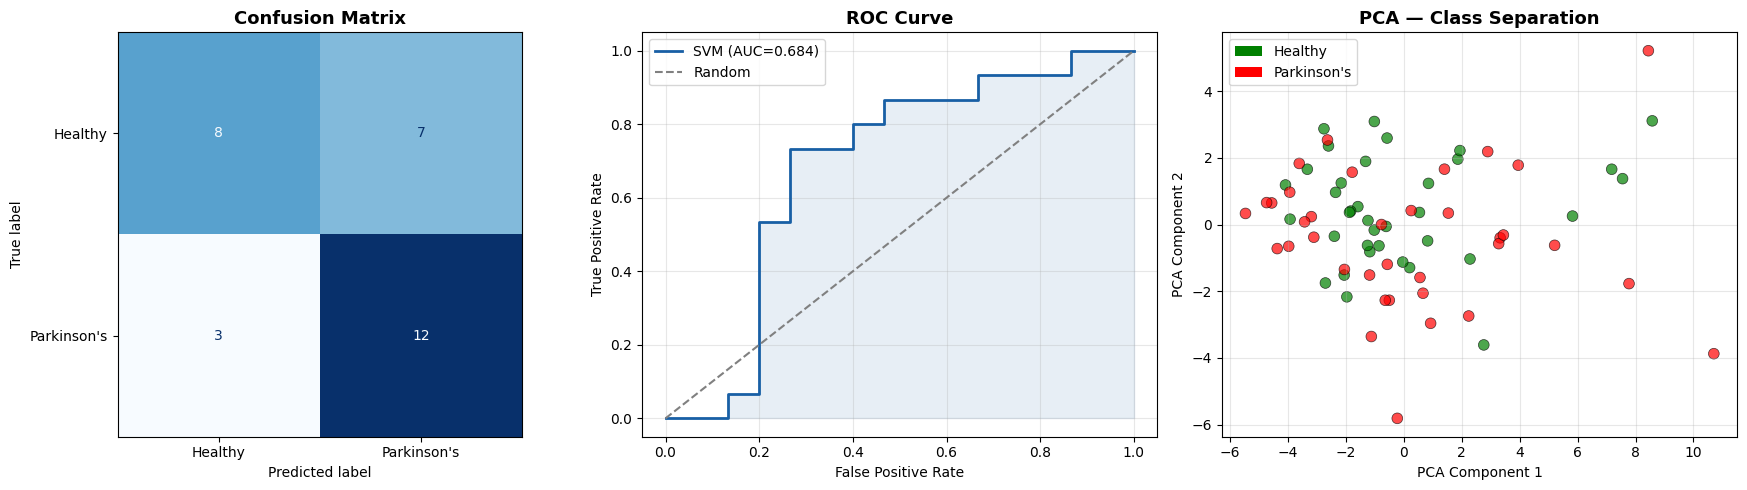

In [14]:
# ── PLOTS ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Healthy', "Parkinson's"]
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13,
                   fontweight='bold')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#185FA5', lw=2,
             label=f'SVM (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'--',color='gray',
             label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1,
                     color='#185FA5')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13,
                   fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# PCA scatter plot
# Visualise how well features separate classes
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_train_scaled)

colors = ['green' if l==0 else 'red'
          for l in y_train]
axes[2].scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=colors, alpha=0.7, s=60,
    edgecolors='black', linewidth=0.5
)
axes[2].set_xlabel('PCA Component 1')
axes[2].set_ylabel('PCA Component 2')
axes[2].set_title('PCA — Class Separation',
                   fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', label='Healthy'),
    Patch(facecolor='red', label="Parkinson's")
]
axes[2].legend(handles=legend_elements)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/spiral_svm_evaluation.png',
            dpi=150)
plt.show()

In [15]:
# ── SAVE ALL COMPONENTS ────────────────────────────────────
import os
os.makedirs('../models', exist_ok=True)

# Save SVM model
joblib.dump(final_svm,
            '../models/spiral_svm_model.pkl')

# Save scaler — needed for preprocessing new images
joblib.dump(scaler,
            '../models/spiral_scaler.pkl')

# Save PCA — needed for transforming new images
joblib.dump(pca,
            '../models/spiral_pca.pkl')

# Save feature names
joblib.dump(feature_names,
            '../models/spiral_feature_names.pkl')

print("All components saved:")
print("  spiral_svm_model.pkl")
print("  spiral_scaler.pkl")
print("  spiral_pca.pkl")
print("  spiral_feature_names.pkl")

# ── VERIFY COMPLETE PIPELINE ───────────────────────────────
print("\nVerifying complete pipeline...")

loaded_svm     = joblib.load('../models/spiral_svm_model.pkl')
loaded_scaler  = joblib.load('../models/spiral_scaler.pkl')
loaded_pca     = joblib.load('../models/spiral_pca.pkl')

# Test on first test image
test_img = X_test_img[0]
test_features = extract_spiral_features(test_img)
test_scaled   = loaded_scaler.transform(
    test_features.reshape(1, -1))
test_pca      = loaded_pca.transform(test_scaled)
test_prob     = loaded_svm.predict_proba(test_pca)[0][1]
test_pred     = 1 if test_prob > 0.5 else 0
actual        = y_test[0]

print(f"\nTest image prediction:")
print(f"  Probability:  {test_prob*100:.1f}%")
print(f"  Predicted:    "
      f"{'Parkinson' if test_pred==1 else 'Healthy'}")
print(f"  Actual:       "
      f"{'Parkinson' if actual==1 else 'Healthy'}")
print(f"  Correct:      "
      f"{'Yes ✓' if test_pred==actual else 'No ✗'}")

All components saved:
  spiral_svm_model.pkl
  spiral_scaler.pkl
  spiral_pca.pkl
  spiral_feature_names.pkl

Verifying complete pipeline...

Test image prediction:
  Probability:  59.3%
  Predicted:    Parkinson
  Actual:       Healthy
  Correct:      No ✗
